In [1]:
# Geospatial imports
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import Window
from skimage.transform import resize
from scipy.ndimage import binary_dilation
import cv2

# ML/Data handling imports
from sklearn.model_selection import train_test_split
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchmetrics.classification import BinaryJaccardIndex, BinaryF1Score, BinaryPrecision, BinaryRecall

import os
import matplotlib.pyplot as plt
import glob

/Users/moritzbaumann/Coding/Ocean-Hackathon/BRE01/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ========================================
# CONFIGURATION
# ========================================

# Path to folder containing multiple TIFFs
data_dir = "../data"
raster_dir = f"{data_dir}/raw_tifs"
# Path to the vector labels
vector_path = f"{data_dir}/N_Sentier_du_Littoral_L_Finistere_3857.gpkg"
# Path to the resulting tile directory
tile_dir = f"{data_dir}/tiles"

TILE_SIZE = 4096
TARGET_SIZE = 256
BATCH_SIZE = 16
# Dilate the path to make it wider (more realistic)
PATH_PIXEL_DILATION: int = 40

In [3]:
# ========================================
# STEP 1: LOAD VECTOR DATA ONCE
# ========================================
print("Loading vector data...")
labels = gpd.read_file(vector_path)
print(f"✓ Loaded {len(labels)} path features")

# ========================================
# STEP 2: GET ALL TIFF FILES
# ========================================
tiff_files = sorted(glob.glob(os.path.join(raster_dir, "*.tif")))
print(f"\nFound {len(tiff_files)} TIFF files:")
for tiff_file in tiff_files:
    print(f"  - {os.path.basename(tiff_file)}")

Loading vector data...
✓ Loaded 1831 path features

Found 12 TIFF files:
  - test10.tif
  - test11.tif
  - test12.tif
  - test13.tif
  - test14.tif
  - test16.tif
  - test17.tif
  - test18.tif
  - test19.tif
  - test20.tif
  - test21.tif
  - test22.tif


In [4]:
# for k in range(5):
#     tiff_files.pop()
# tiff_files = ['../data/raw_tifs/test14.tif',]

In [5]:
# ========================================
# STEP 3: PROCESS EACH TIFF FILE
# ========================================

import cv2


def rasterize_paths(paths_gdf, out_meta):
    shapes = ((geom, 1) for geom in paths_gdf.geometry)
    mask = rasterize(
        shapes=shapes,
        out_shape=(out_meta['height'], out_meta['width']),
        transform=out_meta['transform'],
        fill=0,
        dtype='uint8'
    )

    return mask


def generate_tiles_from_tiff(image_path, mask, tile_size=TILE_SIZE,
                             target_size=TARGET_SIZE, out_dir=tile_dir,
                             file_prefix=""):
    """Generate tiles from a single TIFF file"""

    # CRITICAL: Dilate at ORIGINAL resolution before downscaling
    # This ensures the path doesn't disappear during downscaling
    if PATH_PIXEL_DILATION > 0:
        kernel_original = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (PATH_PIXEL_DILATION*2+1, PATH_PIXEL_DILATION*2+1)
        )
        print(
            f"  Dilating paths by {PATH_PIXEL_DILATION} pixels at original resolution...")
        mask = cv2.dilate(mask, kernel_original)

    with rasterio.open(image_path) as src:
        img_width, img_height = src.width, src.height
        tile_count = 0

        for i in range(0, img_width, tile_size):
            for j in range(0, img_height, tile_size):
                window = Window(i, j, tile_size, tile_size)
                img_tile = src.read(window=window)
                mask_tile = mask[j:j+tile_size, i:i+tile_size]

                if img_tile.shape != (4, tile_size, tile_size):
                    continue
                if mask_tile.shape != (tile_size, tile_size):
                    continue

                # Downscale image using cv2 (much faster than skimage)
                img_downscaled = np.zeros(
                    (4, target_size, target_size), dtype=img_tile.dtype)
                for band in range(4):
                    img_downscaled[band] = cv2.resize(
                        img_tile[band],
                        (target_size, target_size),
                        interpolation=cv2.INTER_LINEAR
                    )

                # Downscale mask using cv2
                # Use INTER_LINEAR for masks to preserve partial coverage, then threshold
                mask_downscaled = cv2.resize(
                    mask_tile.astype(np.float32),
                    (target_size, target_size),
                    interpolation=cv2.INTER_LINEAR
                )
                # Threshold to binary (anything >0.3 becomes 1)
                mask_downscaled = (mask_downscaled > 0.3).astype(np.uint8)

                # Save with file prefix to avoid overwrites
                np.save(os.path.join(
                    out_dir, f"{file_prefix}_img_{i}_{j}.npy"), img_downscaled)
                np.save(os.path.join(
                    out_dir, f"{file_prefix}_mask_{i}_{j}.npy"), mask_downscaled)
                tile_count += 1

        return tile_count


# Create output directory
os.makedirs(tile_dir, exist_ok=True)

# Process each TIFF file
total_tiles = 0
for tiff_idx, tiff_path in enumerate(tiff_files):
    print(f"\n{'='*60}")
    print(
        f"Processing TIFF {tiff_idx+1}/{len(tiff_files)}: {os.path.basename(tiff_path)}")
    print(f"{'='*60}")

    # Create a unique prefix for this TIFF's tiles
    file_prefix = f"tiff{tiff_idx:02d}"

    # Load raster and rasterize vector data for this TIFF
    try:
        with rasterio.open(tiff_path) as src:
            print(f"  Dimensions: {src.width} x {src.height}")
            print(f"  CRS: {src.crs}")
            print(f"  Rasterizing vector data...")
            mask = rasterize_paths(labels, src.meta)
            print(
                f"  Mask shape: {mask.shape}, unique values: {np.unique(mask)}")

        # Generate tiles
        print(f"  Generating tiles...")
        tile_count = generate_tiles_from_tiff(
            tiff_path, mask,
            tile_size=TILE_SIZE,
            target_size=TARGET_SIZE,
            out_dir=tile_dir,
            file_prefix=file_prefix
        )

        print(f"  ✓ Generated {tile_count} tiles from this TIFF")
        total_tiles += tile_count

    except Exception as e:
        print(f"  ✗ Error processing {os.path.basename(tiff_path)}: {str(e)}")
        continue

print(f"\n{'='*60}")
print(
    f"✓ COMPLETE: Generated {total_tiles} tiles from {len(tiff_files)} TIFF files")
print(f"{'='*60}")


Processing TIFF 1/12: test10.tif
  Dimensions: 55010 x 34092
  CRS: EPSG:3857
  Rasterizing vector data...
  Mask shape: (34092, 55010), unique values: [0 1]
  Generating tiles...
  Dilating paths by 40 pixels at original resolution...
  ✓ Generated 104 tiles from this TIFF

Processing TIFF 2/12: test11.tif
  Dimensions: 45257 x 28048
  CRS: EPSG:3857
  Rasterizing vector data...
  Mask shape: (28048, 45257), unique values: [0 1]
  Generating tiles...
  Dilating paths by 40 pixels at original resolution...
  ✓ Generated 66 tiles from this TIFF

Processing TIFF 3/12: test12.tif
  Dimensions: 25201 x 15618
  CRS: EPSG:3857
  Rasterizing vector data...
  Mask shape: (15618, 25201), unique values: [0 1]
  Generating tiles...
  Dilating paths by 40 pixels at original resolution...
  ✓ Generated 18 tiles from this TIFF

Processing TIFF 4/12: test13.tif
  Dimensions: 50402 x 31236
  CRS: EPSG:3857
  Rasterizing vector data...
  Mask shape: (31236, 50402), unique values: [0 1]
  Generating ti

In [4]:
# ========================================
# STEP 4: VERIFY TILES
# ========================================
print("\nVerifying generated tiles...")
img_files = sorted(glob.glob(os.path.join(tile_dir, "*_img_*.npy")))
mask_files = sorted(glob.glob(os.path.join(tile_dir, "*_mask_*.npy")))
print(f"Found {len(img_files)} image tiles and {len(mask_files)} mask tiles")


Verifying generated tiles...
Found 476 image tiles and 476 mask tiles



Visualizing sample tiles from each TIFF...
Dimensions of raster 'tiff00': (4, 256, 256)
Dimensions of mask 'tiff00': (256, 256)


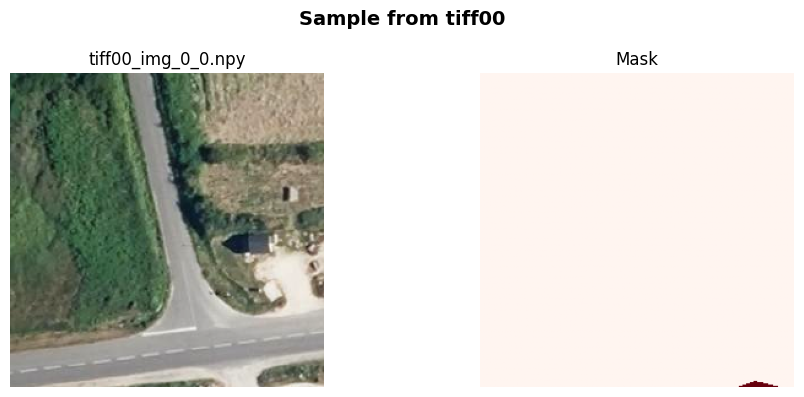

Dimensions of raster 'tiff01': (4, 256, 256)
Dimensions of mask 'tiff01': (256, 256)


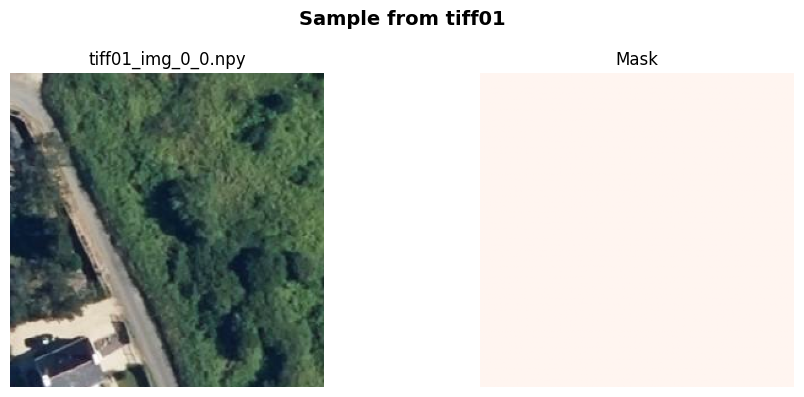

Dimensions of raster 'tiff02': (4, 256, 256)
Dimensions of mask 'tiff02': (256, 256)


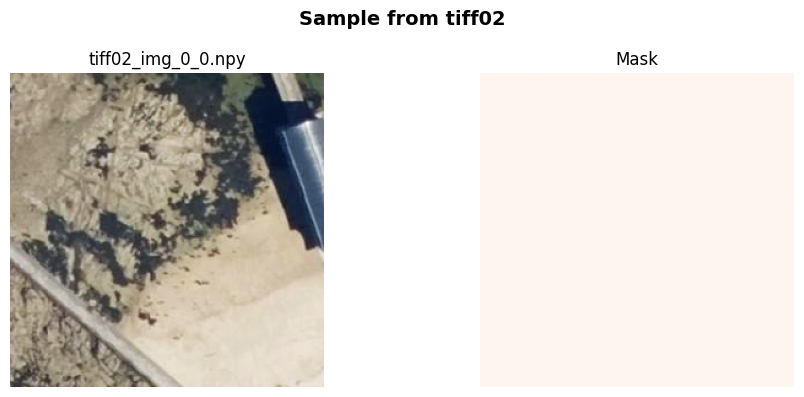

Dimensions of raster 'tiff03': (4, 256, 256)
Dimensions of mask 'tiff03': (256, 256)


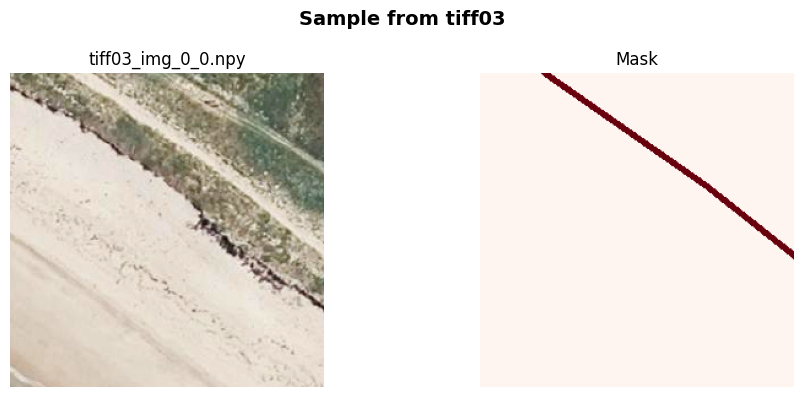

Dimensions of raster 'tiff04': (4, 256, 256)
Dimensions of mask 'tiff04': (256, 256)


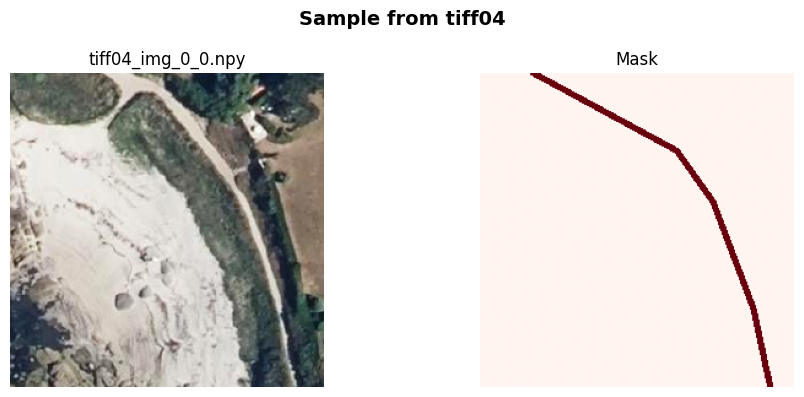

Dimensions of raster 'tiff05': (4, 256, 256)
Dimensions of mask 'tiff05': (256, 256)


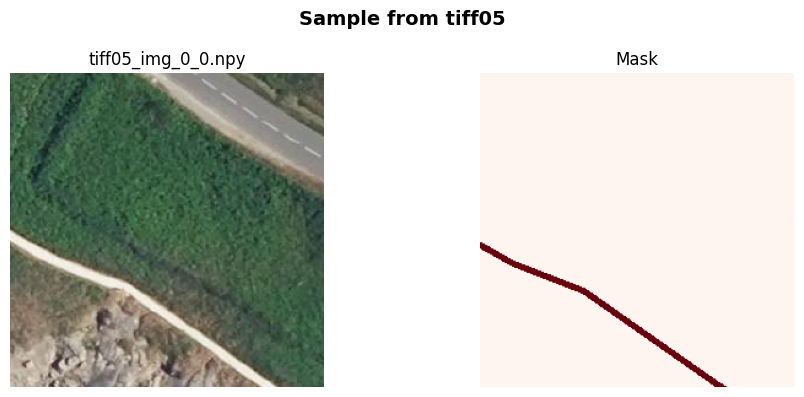

Dimensions of raster 'tiff06': (4, 256, 256)
Dimensions of mask 'tiff06': (256, 256)


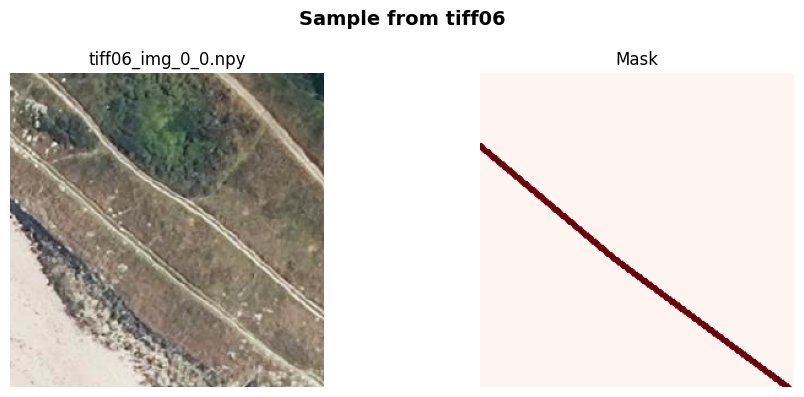

Dimensions of raster 'tiff07': (4, 256, 256)
Dimensions of mask 'tiff07': (256, 256)


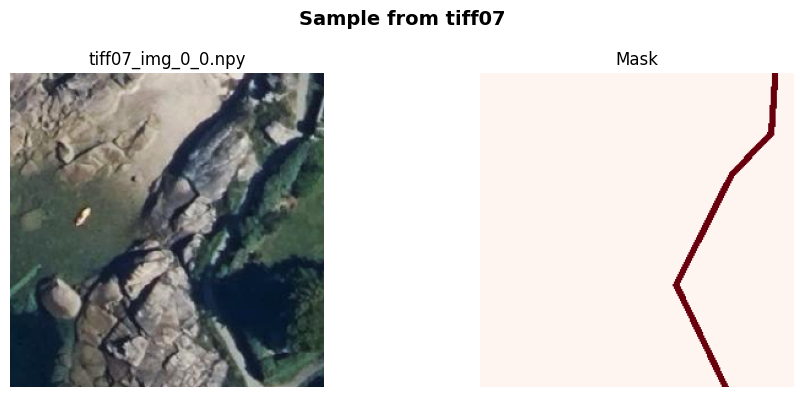

Dimensions of raster 'tiff08': (4, 256, 256)
Dimensions of mask 'tiff08': (256, 256)


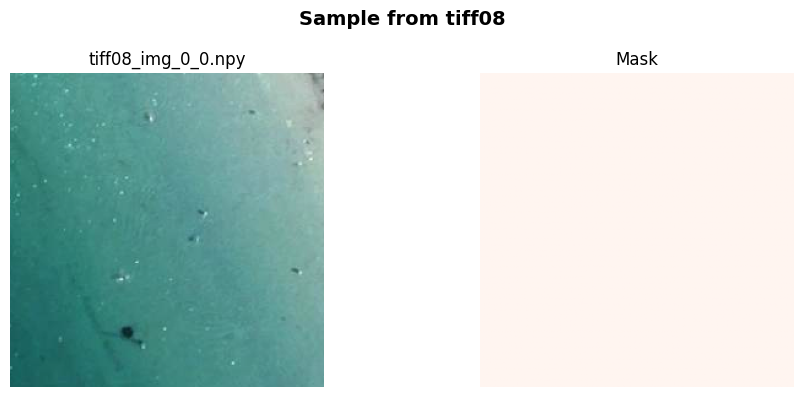

Dimensions of raster 'tiff09': (4, 256, 256)
Dimensions of mask 'tiff09': (256, 256)


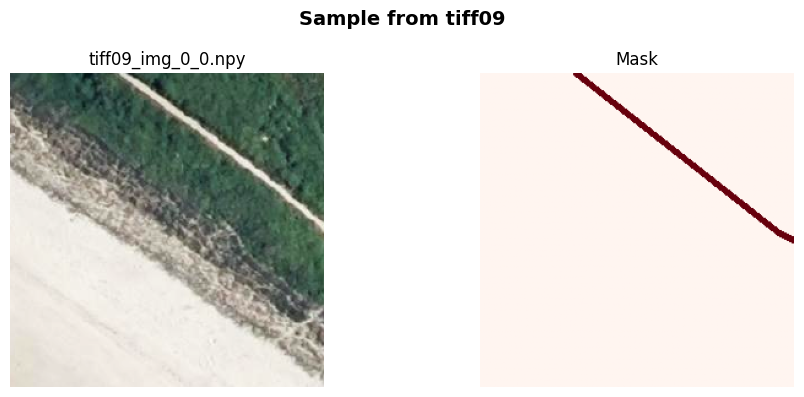


✓ All TIFF files processed and tiles generated!


In [5]:
# ========================================
# STEP 5: VISUALIZE SAMPLES FROM DIFFERENT TIFFS
# ========================================
from collections import defaultdict
print("\nVisualizing sample tiles from each TIFF...")

# Group tiles by TIFF source
tiles_by_tiff = defaultdict(list)
for img_file in img_files:
    # Extract tiff prefix (e.g., "tiff00" from "tiff00_img_0_0.npy")
    prefix = os.path.basename(img_file).split('_img_')[0]
    tiles_by_tiff[prefix].append(img_file)

# Show one tile from each TIFF
for prefix in sorted(tiles_by_tiff.keys())[:10]:  # Show first 5 TIFFs
    img_file = tiles_by_tiff[prefix][0]
    mask_file = img_file.replace("_img_", "_mask_")

    img = np.load(img_file)
    mask = np.load(mask_file)

    print(f"Dimensions of raster '{prefix}': {img.shape}")
    print(f"Dimensions of mask '{prefix}': {mask.shape}")

    # Convert to (H, W, bands) for display
    if img.shape[0] < img.shape[-1]:
        img = np.moveaxis(img, 0, -1)

    # Normalize for display
    img_disp = img[:, :, :3]
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Sample from {prefix}", fontsize=14, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.imshow(img_disp)
    plt.title(os.path.basename(img_file))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="Reds")
    plt.title("Mask")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print("\n✓ All TIFF files processed and tiles generated!")

In [6]:
# ========================================
# STEP 6: CUSTOM DATASET
# ========================================
class TileDataset(Dataset):
    def __init__(self, img_paths, mask_paths, normalize=True, preload=True):
        self.normalize = normalize
        self.mean_rgb = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std_rgb = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        if preload:
            print("Preloading all tiles into memory...")
            self.images = [np.load(p) for p in img_paths]
            self.masks = [np.load(p) for p in mask_paths]
            self.img_paths = None
            self.mask_paths = None
            print(f"✓ Loaded {len(self.images)} tiles")
        else:
            self.images = None
            self.masks = None
            self.img_paths = img_paths
            self.mask_paths = mask_paths

    def __len__(self):
        return len(self.images) if self.images else len(self.img_paths)

    def __getitem__(self, idx):
        if self.images is not None:
            img = self.images[idx]
            mask = self.masks[idx]
        else:
            img = np.load(self.img_paths[idx])
            mask = np.load(self.mask_paths[idx])

        img_tensor = torch.tensor(img, dtype=torch.float32)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        if self.normalize:
            img_tensor = img_tensor / 255.0
            # Normalize RGB channels (0-2) with ImageNet stats
            img_tensor[:3] = (img_tensor[:3] - self.mean_rgb) / self.std_rgb
            # NIR channel (3) stays as-is (already 0-1 after division)

        return img_tensor, mask_tensor

In [7]:
# ========================================
# STEP 7: SPLIT DATA AND CREATE DATALOADERS
# ========================================
print("\nCreating train/val split...")

# Get file paths (NOT the actual data!)
img_files = sorted(glob.glob(os.path.join(tile_dir, "*img_*.npy")))
mask_files = [f.replace("img_", "mask_") for f in img_files]

# Split paths only
img_train, img_val, mask_train, mask_val = train_test_split(
    img_files, mask_files, test_size=0.2, random_state=42
)

print(f"Train tiles: {len(img_train)}")
print(f"Validation tiles: {len(img_val)}")

# Create datasets
train_dataset = TileDataset(img_train, mask_train, normalize=True)
val_dataset = TileDataset(img_val, mask_val, normalize=True)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Test dataloader
print("\nTesting dataloader...")
for images, masks in train_loader:
    print(f"Batch shape: {images.shape}, {masks.shape}")
    print(f"Image range: [{images.min():.2f}, {images.max():.2f}]")
    print(f"Mask range: [{masks.min():.2f}, {masks.max():.2f}]")
    break


Creating train/val split...
Train tiles: 380
Validation tiles: 96
Preloading all tiles into memory...
✓ Loaded 380 tiles
Preloading all tiles into memory...
✓ Loaded 96 tiles

Testing dataloader...
Batch shape: torch.Size([16, 4, 256, 256]), torch.Size([16, 1, 256, 256])
Image range: [-1.86, 2.64]
Mask range: [0.00, 1.00]


In [8]:
# ========================================
# STEP 8: CALCULATE CLASS WEIGHTS
# ========================================
print("\nCalculating class weights from training data...")

total_pixels = 0
positive_pixels = 0

# Sample masks to calculate imbalance (use all or subset for speed)
sample_size = min(100, len(mask_train))
for mask_path in mask_train[:sample_size]:
    mask = np.load(mask_path)
    total_pixels += mask.size
    positive_pixels += mask.sum()

pos_ratio = positive_pixels / total_pixels
neg_ratio = 1 - pos_ratio

print(f"Positive pixels: {pos_ratio*100:.3f}%")
print(f"Negative pixels: {neg_ratio*100:.3f}%")

# Calculate pos_weight for BCE loss
pos_weight = neg_ratio / pos_ratio if pos_ratio > 0 else 1.0
print(f"Positive class weight: {pos_weight:.2f}")


Calculating class weights from training data...
Positive pixels: 0.481%
Negative pixels: 99.519%
Positive class weight: 207.03


In [ ]:
# ========================================
# STEP 9: MODEL SETUP
# ========================================
print("\nSetting up model...")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model = smp.Unet(
    encoder_name="efficientnet-b0",  # or resnet34 -> more power, slower
    encoder_weights="imagenet",
    in_channels=4,
    classes=1,
    activation=None
).to(device)

# Loss functions (Solution 1: Weighted/Focal Loss)
dice_loss = smp.losses.DiceLoss(mode="binary")
focal_loss = smp.losses.FocalLoss(mode="binary", alpha=0.25, gamma=2.0)


def combined_loss(preds, targets):
    return dice_loss(preds, targets) + focal_loss(preds, targets)


print("Using Dice + Focal Loss to handle class imbalance")


# Optimizer & Learning Rate
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
f1_metric = BinaryF1Score(threshold=0.5).to(device)
precision_metric = BinaryPrecision(threshold=0.5).to(device)
recall_metric = BinaryRecall(threshold=0.5).to(device)

# Learning rate scheduler (optional)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


Setting up model...
Using device: cpu
Using Dice + Focal Loss to handle class imbalance


In [10]:
# ========================================
# STEP 10: TRAINING LOOP
# ========================================
print("\nStarting training...")

num_epochs = 20

# Initialize tracking lists
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_f1': [],
    'val_precision': [],
    'val_recall': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        preds = model(images)
        loss = combined_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()

        # Add gradient clipping to prevent instability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss, val_iou, val_f1, val_precision, val_recall = 0.0, 0.0, 0.0, 0.0, 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)

            loss = combined_loss(preds, masks)
            val_loss += loss.item() * images.size(0)

            preds_sigmoid = torch.sigmoid(preds)
            val_iou += iou_metric(preds_sigmoid, masks.int()
                                  ).item() * images.size(0)
            val_f1 += f1_metric(preds_sigmoid, masks.int()
                                ).item() * images.size(0)
            val_precision += precision_metric(preds_sigmoid,
                                              masks.int()).item() * images.size(0)
            val_recall += recall_metric(preds_sigmoid,
                                        masks.int()).item() * images.size(0)

    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)
    val_f1 /= len(val_loader.dataset)
    val_precision /= len(val_loader.dataset)
    val_recall /= len(val_loader.dataset)

    # Store metrics in history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)

    # Learning rate scheduling
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(
        f"Val Loss:   {val_loss:.4f} | IoU: {val_iou:.4f} | F1: {val_f1:.4f}")
    print(f"Precision:  {val_precision:.4f} | Recall: {val_recall:.4f}")

    # Warning if model is predicting all zeros
    if val_recall < 0.1:
        print("⚠️  WARNING: Very low recall - model may be predicting mostly zeros!")

print("\n✓ Training complete!")

# Save model
torch.save(model.state_dict(),
           "../trained_models/path_segmentation_model_lr0.0005.pth")
print("Model saved!")


Starting training...

Epoch [1/20]
Train Loss: 1.0602
Val Loss:   1.0077 | IoU: 0.0700 | F1: 0.1300
Precision:  0.0943 | Recall: 0.2266

Epoch [2/20]
Train Loss: 0.9668
Val Loss:   0.9837 | IoU: 0.1467 | F1: 0.2547
Precision:  0.2288 | Recall: 0.2989

Epoch [3/20]
Train Loss: 0.9816
Val Loss:   0.9801 | IoU: 0.1246 | F1: 0.2158
Precision:  0.2192 | Recall: 0.2558

Epoch [4/20]
Train Loss: 0.9649
Val Loss:   0.9746 | IoU: 0.1066 | F1: 0.1901
Precision:  0.3410 | Recall: 0.1515

Epoch [5/20]
Train Loss: 0.9351
Val Loss:   0.9203 | IoU: 0.2219 | F1: 0.3621
Precision:  0.2960 | Recall: 0.4879

Epoch [6/20]
Train Loss: 0.8696
Val Loss:   0.8714 | IoU: 0.1815 | F1: 0.3056
Precision:  0.2814 | Recall: 0.3470

Epoch [7/20]
Train Loss: 0.7751
Val Loss:   0.9324 | IoU: 0.0649 | F1: 0.1165
Precision:  0.4279 | Recall: 0.0825
⚠️  WARNING: Very low recall - model may be predicting mostly zeros!

Epoch [8/20]
Train Loss: 0.6329
Val Loss:   0.7262 | IoU: 0.2019 | F1: 0.3351
Precision:  0.3710 | Reca


Generating training plots...


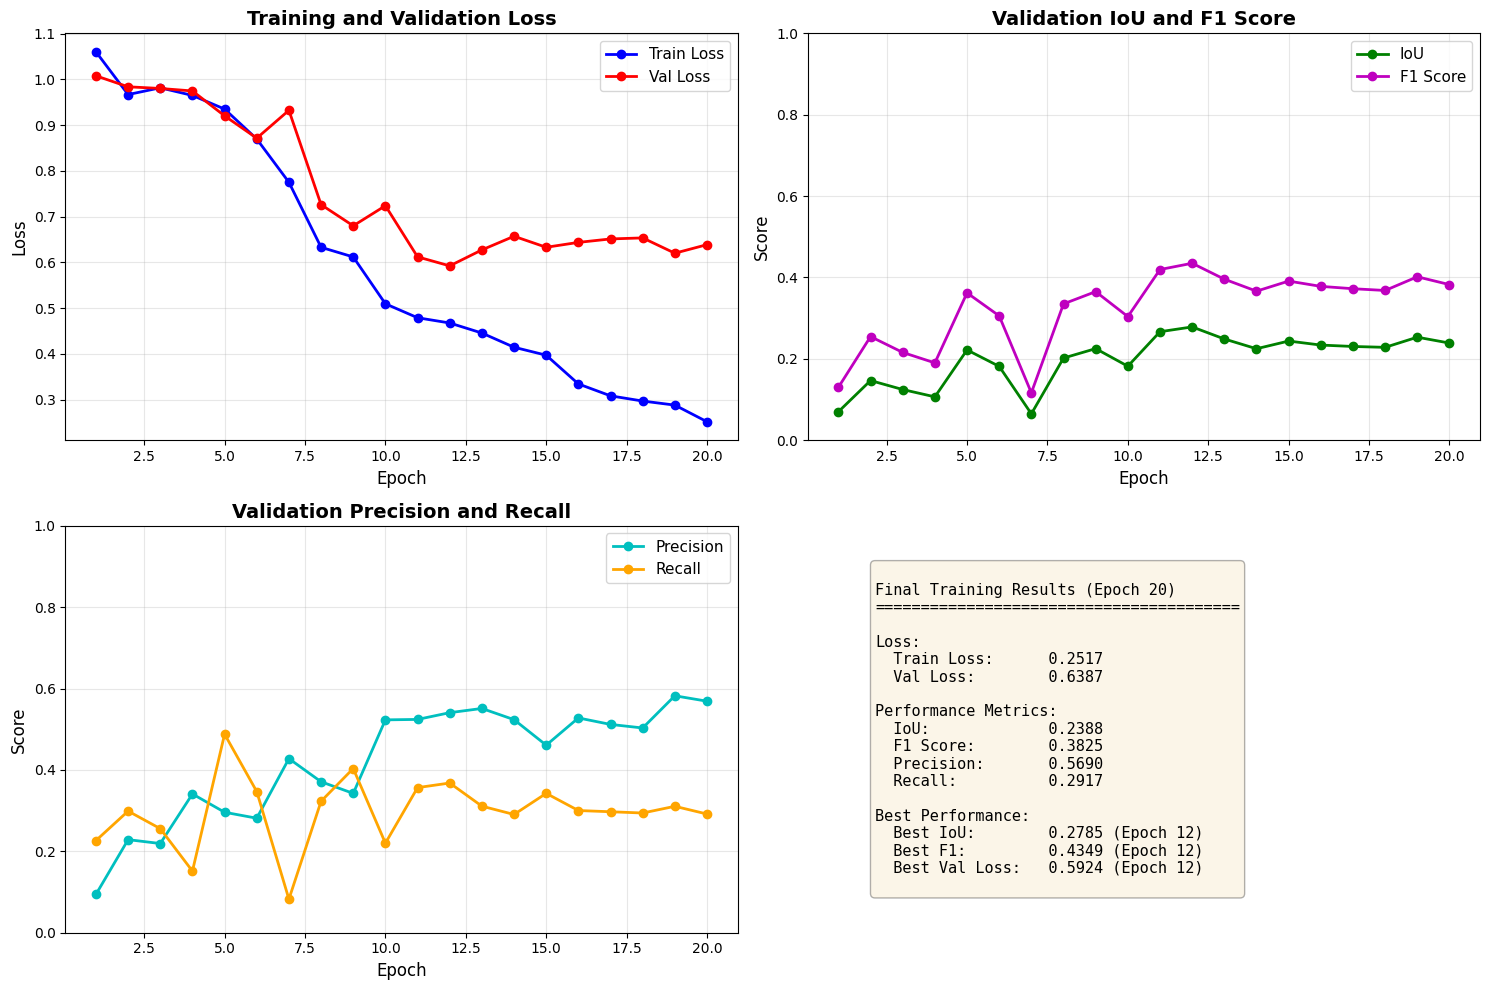

✓ Training plots saved to '../training_results.png'


In [11]:
# ========================================
# STEP 11: PLOT TRAINING RESULTS
# ========================================
print("\nGenerating training plots...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
epochs_range = range(1, num_epochs + 1)

# Plot 1: Loss
axes[0, 0].plot(epochs_range, history['train_loss'],
                'b-o', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'],
                'r-o', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss',
                     fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: IoU and F1 Score
axes[0, 1].plot(epochs_range, history['val_iou'],
                'g-o', label='IoU', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_f1'],
                'm-o', label='F1 Score', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_title('Validation IoU and F1 Score',
                     fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Plot 3: Precision and Recall
axes[1, 0].plot(epochs_range, history['val_precision'],
                'c-o', label='Precision', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_recall'], 'orange',
                marker='o', label='Recall', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Score', fontsize=12)
axes[1, 0].set_title('Validation Precision and Recall',
                     fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Plot 4: Summary metrics table
axes[1, 1].axis('off')
summary_text = f"""
Final Training Results (Epoch {num_epochs})
{'='*40}

Loss:
  Train Loss:      {history['train_loss'][-1]:.4f}
  Val Loss:        {history['val_loss'][-1]:.4f}

Performance Metrics:
  IoU:             {history['val_iou'][-1]:.4f}
  F1 Score:        {history['val_f1'][-1]:.4f}
  Precision:       {history['val_precision'][-1]:.4f}
  Recall:          {history['val_recall'][-1]:.4f}

Best Performance:
  Best IoU:        {max(history['val_iou']):.4f} (Epoch {history['val_iou'].index(max(history['val_iou']))+1})
  Best F1:         {max(history['val_f1']):.4f} (Epoch {history['val_f1'].index(max(history['val_f1']))+1})
  Best Val Loss:   {min(history['val_loss']):.4f} (Epoch {history['val_loss'].index(min(history['val_loss']))+1})
"""

axes[1, 1].text(0.1, 0.5, summary_text,
                fontsize=11,
                family='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('../training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training plots saved to '../training_results.png'")

In [13]:
# ========================================
# STEP 12: MODEL ARCHITECTURE SUMMARY
# ========================================

def print_model_summary(model, optimizer, scheduler, device):
    """
    Print a comprehensive summary of the model architecture and training configuration
    """
    print("\n" + "="*70)
    print("MODEL ARCHITECTURE & TRAINING CONFIGURATION".center(70))
    print("="*70)

    # Model Architecture
    print("\n📐 MODEL ARCHITECTURE")
    print("-" * 70)
    print(f"  Architecture:          {model.__class__.__name__}")
    print(f"  Encoder Weights:       ImageNet (pretrained)")
    print(f"  Input Channels:        4 (RGB + NIR)")
    print(f"  Output Classes:        1 (binary segmentation)")
    print(f"  Activation:            Sigmoid")
    print(f"  Device:                {device.upper()}")

    # Model Parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel()
                           for p in model.parameters() if p.requires_grad)
    print(f"  Total Parameters:      {total_params:,}")
    print(f"  Trainable Parameters:  {trainable_params:,}")
    print(
        f"  Model Size:            {total_params * 4 / (1024**2):.2f} MB (FP32)")

    # Loss Function
    print("\n📊 LOSS FUNCTION")
    print("-" * 70)
    print(f"  Loss Type:             Combined Loss")
    print(f"    └─ Dice Loss:        Weight = 1.0")
    print(f"    └─ Focal Loss:       Weight = 1.0, α=0.25, γ=2.0")
    print(f"  Purpose:               Handle severe class imbalance")

    # Optimizer
    print("\n⚙️  OPTIMIZER")
    print("-" * 70)
    print(f"  Optimizer:             {optimizer.__class__.__name__}")
    print(f"  Learning Rate:         {optimizer.param_groups[0]['lr']}")
    if 'weight_decay' in optimizer.param_groups[0]:
        print(
            f"  Weight Decay:          {optimizer.param_groups[0]['weight_decay']}")
    if 'betas' in optimizer.param_groups[0]:
        print(f"  Betas:                 {optimizer.param_groups[0]['betas']}")
    print(f"  Gradient Clipping:     max_norm=1.0")

    # Learning Rate Scheduler
    print("\n📉 LEARNING RATE SCHEDULER")
    print("-" * 70)
    print(f"  Scheduler:             {scheduler.__class__.__name__}")
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        print(f"  Mode:                  {scheduler.mode}")
        print(f"  Factor:                {scheduler.factor}")
        print(f"  Patience:              {scheduler.patience}")

    # Data Configuration
    print("\n🗂️  DATA CONFIGURATION")
    print("-" * 70)
    print(
        f"  Tile Size:             {TILE_SIZE}x{TILE_SIZE} → {TARGET_SIZE}x{TARGET_SIZE}")
    print(f"  Batch Size:            {BATCH_SIZE}")
    print(f"  Path Dilation:         {PATH_PIXEL_DILATION} pixels")
    print(f"  Train/Val Split:       80% / 20%")
    print(f"  Normalization:         ImageNet (RGB) + [0,1] (NIR)")

    # Metrics
    print("\n📈 EVALUATION METRICS")
    print("-" * 70)
    print(f"  Primary Metric:        IoU (Intersection over Union)")
    print(f"  Additional Metrics:    F1-Score, Precision, Recall")
    print(f"  Threshold:             0.5")

    # Training Configuration
    print("\n🎯 TRAINING CONFIGURATION")
    print("-" * 70)
    print(f"  Number of Epochs:      {num_epochs}")
    print(
        f"  Early Stopping:        Enabled (patience={scheduler.patience if hasattr(scheduler, 'patience') else 'N/A'})")
    print(f"  Model Checkpoint:      Best IoU")
    print(
        f"  Mixed Precision:       {'Enabled' if torch.cuda.is_available() else 'Disabled'}")

    print("\n" + "="*70 + "\n")


# Call the function after setting up your model
print_model_summary(model, optimizer, scheduler, device)

# Optional: Save summary to text file for easy reference
with open('../model_summary.txt', 'w') as f:
    import sys
    old_stdout = sys.stdout
    sys.stdout = f
    print_model_summary(model, optimizer, scheduler, device)
    sys.stdout = old_stdout

print("✓ Model summary saved to '../model_summary.txt'")


             MODEL ARCHITECTURE & TRAINING CONFIGURATION              

📐 MODEL ARCHITECTURE
----------------------------------------------------------------------
  Architecture:          Unet
  Encoder Weights:       ImageNet (pretrained)
  Input Channels:        4 (RGB + NIR)
  Output Classes:        1 (binary segmentation)
  Activation:            Sigmoid
  Device:                CPU
  Total Parameters:      6,251,757
  Trainable Parameters:  6,251,757
  Model Size:            23.85 MB (FP32)

📊 LOSS FUNCTION
----------------------------------------------------------------------
  Loss Type:             Combined Loss
    └─ Dice Loss:        Weight = 1.0
    └─ Focal Loss:       Weight = 1.0, α=0.25, γ=2.0
  Purpose:               Handle severe class imbalance

⚙️  OPTIMIZER
----------------------------------------------------------------------
  Optimizer:             Adam
  Learning Rate:         0.000125
  Weight Decay:          0
  Betas:                 (0.9, 0.999)
  Gradien